In [67]:
import psycopg2
import pandas as pd
import numpy as np
import time

import random
import bisect
import pickle
import matplotlib.pyplot as plt  
from datetime import timedelta
import datetime as dt
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency  
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [68]:
conn = psycopg2.connect(
    dbname='devdevicedata',
    user='momenzadeha',
    password='RoxanaMs!123!',
    host='csmc-dev-redshift02.cpjbnhfho8k1.us-west-2.redshift.amazonaws.com',
    port='5439')

In [69]:
import pandas as pd
import numpy as np

# --- Loratadine exposures ---
query_lor = """
SELECT mrn_deid, csn_deid, start_date, end_date, medication_nm
FROM ml_meyer_lab.amanda_00004042_meds
WHERE medication_nm = 'LORATADINE 10 MG PO TABS'
"""
lor = pd.read_sql_query(query_lor, conn)

lor['start_date'] = pd.to_datetime(lor['start_date'], errors='coerce')
lor['end_date']   = pd.to_datetime(lor['end_date'], errors='coerce')

# Aggregate to encounter-level loratadine window
lor_window = (
    lor.groupby(['mrn_deid', 'csn_deid'])
       .agg(
           lor_start=('start_date', 'min'),
           lor_end=('end_date', 'max')
       )
       .reset_index()
)
lor_window['loratadine_flag'] = 1


C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\2852277170.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lor = pd.read_sql_query(query_lor, conn)


In [70]:
loratadine_exposure

,mrn_deid,csn_deid,loratadine_flag
0,00002399F353098ACA4A,15FFD1F9D1087A41F5C2,1
1,00120A7136C4882F8B15,771956E836A4792B8134,1
2,001488F80C25321D93B0,0777A38FEADFC013F872,1
3,002841A845647BF32AC0,39E7ED9DB1AE1A860F26,1
4,0028DDB6C344AF3D40BB,D583D02D2D4DA3E82C20,1
...,...,...,...
44822,FFEA0769D23ACD220A3C,F390C806BA35B18E3B82,1
44823,FFF06450CC71B69A8E53,A76B4EE9810045507164,1
44824,FFF1C4B6AE141FE54D8D,27ADC49AC46D843F9541,1
44825,FFF674146793978B213F,F17A36B239937F083BC4,1


In [71]:
loratadine

,mrn_deid,csn_deid,start_date,end_date,medication_nm
0,F76B0674C1D38D8BEA9D,DA2B5C58BF3463E82BE0,2011-04-02,2011-04-02,LORATADINE 10 MG PO TABS
1,FE54A5A621D675DCE4CF,2FF2BD24D48F6DD6F378,2012-02-22,2012-02-23,LORATADINE 10 MG PO TABS
2,FE54A5A621D675DCE4CF,2FF2BD24D48F6DD6F378,2012-02-22,2012-02-23,LORATADINE 10 MG PO TABS
3,8A7716A614F5BD409152,B14B08C4D3ADC5FC60C6,2013-06-03,2013-06-03,LORATADINE 10 MG PO TABS
4,BC1EF9EE9762DB23A6DD,2D6FD747930BB0B81DF7,2013-10-24,2013-11-01,LORATADINE 10 MG PO TABS
...,...,...,...,...,...
121543,10775476599BDDACA464,9E2B8FA0E307FBC406E5,2021-02-20,2021-03-05,LORATADINE 10 MG PO TABS
121544,490E30D073411DF57BC3,ED6BCF7147C86DC9931A,2021-01-15,2021-01-15,LORATADINE 10 MG PO TABS
121545,3DB2FEF1E36648940B27,CE96381533562D95E7AB,2022-06-28,2022-07-20,LORATADINE 10 MG PO TABS
121546,98B92C292FB30A119313,061A8B6931243EA576F0,2021-11-17,2022-11-15,LORATADINE 10 MG PO TABS


In [72]:
query_iron = """
SELECT mrn_deid, csn_deid, result_time, component_name, ord_value
FROM ml_meyer_lab.amanda_00004042_labs
WHERE component_name = 'TOTAL IRON'
"""
iron = pd.read_sql_query(query_iron, conn)

iron['result_time'] = pd.to_datetime(iron['result_time'], errors='coerce')

# Clean ord_value -> numeric
iron['ord_value'] = (
    iron['ord_value']
    .astype(str)
    .str.strip()
    .replace({'': np.nan})
)
iron['ord_value'] = pd.to_numeric(iron['ord_value'], errors='coerce')


C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\1449759652.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  iron = pd.read_sql_query(query_iron, conn)


In [31]:
# Inner merge: only encounters that have loratadine AND iron labs
iron_lor = iron.merge(
    lor_window[['mrn_deid', 'csn_deid', 'lor_start', 'lor_end']],
    on=['mrn_deid', 'csn_deid'],
    how='inner'
)

# Keep only iron results during the loratadine exposure window
mask_in_window = (iron_lor['result_time'] >= iron_lor['lor_start']) & \
                 (iron_lor['result_time'] <= iron_lor['lor_end'])

iron_lor = iron_lor[mask_in_window].copy()

# Now compute mean TOTAL IRON during loratadine window per encounter
iron_lor_enc = (
    iron_lor.groupby(['mrn_deid', 'csn_deid'])['ord_value']
            .mean()
            .reset_index()
            .rename(columns={'ord_value': 'mean_total_iron_lor_window'})
)

# Exposed cohort with outcome
exposed_df = (
    lor_window
    .merge(iron_lor_enc, on=['mrn_deid', 'csn_deid'], how='left')
)


In [32]:
# All encounters with TOTAL IRON labs (anyone, exposed or not)
iron_enc_all = (
    iron.groupby(['mrn_deid', 'csn_deid'])['ord_value']
        .mean()
        .reset_index()
        .rename(columns={'ord_value': 'mean_total_iron_all'})
)

# Mark which encounters ever had loratadine
lor_encounters = lor_window[['mrn_deid', 'csn_deid']].drop_duplicates()
lor_encounters['loratadine_flag'] = 1

# Full encounter list with iron
encounters_iron = iron_enc_all.merge(
    lor_encounters,
    on=['mrn_deid', 'csn_deid'],
    how='left'
)
encounters_iron['loratadine_flag'] = encounters_iron['loratadine_flag'].fillna(0).astype(int)

# For exposed encounters, replace mean_total_iron_all with iron-in-window
encounters_iron = encounters_iron.merge(
    iron_lor_enc,
    on=['mrn_deid', 'csn_deid'],
    how='left'
)

# Final outcome variable: iron_mean
# - Exposed: use mean_total_iron_lor_window
# - Controls: use mean_total_iron_all
encounters_iron['iron_mean'] = np.where(
    encounters_iron['loratadine_flag'] == 1,
    encounters_iron['mean_total_iron_lor_window'],
    encounters_iron['mean_total_iron_all']
)

# Drop encounters with no usable iron value
encounters_iron = encounters_iron.dropna(subset=['iron_mean'])


In [33]:
query_demo = """
SELECT mrn_deid, csn_deid, birth_date, sex, race_1, ethnic_group,
       bmi, inp_adm_date, disch_date_time, admit_diag, insurance_cat
FROM ml_meyer_lab.amanda_00004042_cohort
"""
demo = pd.read_sql_query(query_demo, conn)

# Convert datetimes
demo['birth_date'] = pd.to_datetime(demo['birth_date'], errors='coerce')
demo['inp_adm_date'] = pd.to_datetime(demo['inp_adm_date'], errors='coerce')
demo['disch_date_time'] = pd.to_datetime(demo['disch_date_time'], errors='coerce')


C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\480421819.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  demo = pd.read_sql_query(query_demo, conn)


In [34]:
# Reference time = time of iron lab used for outcome
# For exposed: lor_start (we used iron-in-window)
# For controls: mean iron across encounter, so use earliest iron lab

# Compute first iron lab time per encounter
first_iron_time = (
    iron.groupby(['mrn_deid','csn_deid'])['result_time']
        .min()
        .reset_index()
        .rename(columns={'result_time':'iron_first_time'})
)

# For exposed: override with lor_start
ref_time = first_iron_time.merge(
    lor_window[['mrn_deid','csn_deid','lor_start']],
    on=['mrn_deid','csn_deid'],
    how='left'
)

# Use lor_start when available, otherwise iron_first_time
ref_time['ref_time'] = np.where(
    ref_time['lor_start'].notna(),
    ref_time['lor_start'],
    ref_time['iron_first_time']
)


In [35]:
# Merge ref_time into demo
demo = demo.merge(ref_time[['mrn_deid','csn_deid','ref_time']],
                  on=['mrn_deid','csn_deid'], how='left')

# Age in years at time of lab/exposure
demo['age'] = (demo['ref_time'] - demo['birth_date']).dt.days / 365.25


In [36]:
demo['length_of_stay'] = (demo['disch_date_time'] - demo['inp_adm_date']).dt.total_seconds() / 86400.0


In [37]:
demo['length_of_stay'] = demo['length_of_stay'].clip(lower=0, upper=60)


In [38]:
demo['insurance_clean'] = demo['insurance_cat'].astype(str).str.upper().str.strip()

demo['insurance_clean'] = np.where(
    demo['insurance_clean'].str.contains('MEDICARE', na=False),
    'Medicare',
    np.where(
        demo['insurance_clean'].isna() | (demo['insurance_clean']=='') | (demo['insurance_clean']=='NONE'),
        'Missing',
        'Other'
    )
)


In [39]:
diag = demo['admit_diag'].astype(str).str.upper()

demo['admit_category'] = np.select(
    [
        # 1. Trauma / Injury
        diag.str.contains('TRAUMA|FRACTURE|LACERATION|INJURY|CONTUSION|FALL|ASSAULT|MVA|MVC'),
        
        # 2. Substance Use
        diag.str.contains('METH|ALCOHOL|ETOH|OPIOID|OVERDOSE|TOXIC|SUBSTANCE'),
        
        # 3. Psychiatric
        diag.str.contains('SUICIDE|HOMICIDE|PSYCH|SCHIZO|DEPRESSION|ANXIETY'),
        
        # 4. Cardiopulmonary
        diag.str.contains('CHEST PAIN|SOB|SHORTNESS OF BREATH|RESPIRATORY|ASTHMA|COPD'),
        
        # 5. Neurologic
        diag.str.contains('STROKE|SEIZURE|AMS|ALTERED|HEADACHE|HEAD TRAUMA|TBI'),
        
        # 6. GI / Abdominal
        diag.str.contains('ABDOM|ABD PAIN|GI BLEED|PANCREAT|HEPAT|LIVER'),
        
        # 7. Infection
        diag.str.contains('SEPSIS|PNEUMONIA|UTI|CELLULITIS|INFECTION')
    ],
    [
        'Trauma',
        'SubstanceUse',
        'Psychiatric',
        'Cardiopulm',
        'Neuro',
        'GI_Abd',
        'Infection'
    ],
    default='Other'
)


In [73]:
demo['admit_category']

0                Other
1                Other
2               Trauma
3               Trauma
4         SubstanceUse
              ...     
604939           Other
604940           Neuro
604941          GI_Abd
604942           Other
604943           Other
Name: admit_category, Length: 604944, dtype: object

In [84]:
demo_cov = demo[
    [
        'mrn_deid',
        'csn_deid',
        'age',
        'sex',
        'race_1',
        'ethnic_group',
        'bmi',
        'length_of_stay',
        'admit_category',
        'insurance_clean'
    ]
].copy()


In [85]:
demo_cov['race_group'] = demo_cov['race_1'].replace({
    r'^WHITE.*'   : 'White',
    r'^BLACK.*'   : 'Black',
    r'^ASIAN.*'   : 'Asian',
    r'^HISPANIC.*': 'Hispanic',
    r'^MENA.*'    : 'MENA',
    r'^NHPI.*'    : 'NHPI',
    r'^UNKNOWN.*' : 'Unknown',
    r'^PATIENT DECLINED.*': 'Declined'
}, regex=True)

demo_cov['race_group'] = demo_cov['race_group'].fillna('Other')


In [86]:
# One-hot encode categorical variables for modeling
categoricals = ['sex', 'race_group', 'ethnic_group', 'admit_category', 'insurance_clean']

demo_cov = pd.get_dummies(demo_cov, columns=categoricals, drop_first=True)


In [87]:
query_pmh_flags = """
SELECT
    mrn_deid,

    -- 1) Chronic kidney disease / ESRD
    MAX(CASE
            WHEN current_icd10_list LIKE '%N18%'   -- CKD
              OR current_icd10_list LIKE '%I12%'   -- HTN with CKD
              OR current_icd10_list LIKE '%I13%'   -- HTN with heart & CKD
              OR current_icd10_list LIKE '%Z99.2%' -- Dependence on dialysis
            THEN 1 ELSE 0
        END) AS pmh_ckd,

    -- 2) Chronic liver disease / cirrhosis
    MAX(CASE
            WHEN current_icd10_list LIKE '%K70%'   -- alcoholic liver disease
              OR current_icd10_list LIKE '%K71%'   -- toxic liver disease
              OR current_icd10_list LIKE '%K72%'   -- hepatic failure
              OR current_icd10_list LIKE '%K74%'   -- fibrosis/cirrhosis
            THEN 1 ELSE 0
        END) AS pmh_chronic_liver,

    -- 3) Anemia / iron deficiency / anemia of chronic disease
    MAX(CASE
            WHEN current_icd10_list LIKE '%D50%'   -- iron deficiency anemia
              OR current_icd10_list LIKE '%D51%'   -- B12 anemia
              OR current_icd10_list LIKE '%D52%'   -- folate anemia
              OR current_icd10_list LIKE '%D53%'   -- other nutritional anemia
              OR current_icd10_list LIKE '%D63%'   -- anemia in chronic disease
              OR current_icd10_list LIKE '%D64%'   -- other anemias
            THEN 1 ELSE 0
        END) AS pmh_anemia,

    -- 4) Iron metabolism disorders / iron overload
    MAX(CASE
            WHEN current_icd10_list LIKE '%E83.1%'  -- disorders of iron metabolism
              OR current_icd10_list LIKE '%E61.1%'  -- iron deficiency
            THEN 1 ELSE 0
        END) AS pmh_iron_disorder,

    -- 5) Malignancy (solid + heme)
    MAX(CASE
            WHEN current_icd10_list LIKE '%C0%'   -- all malignant neoplasms (broad)
              OR current_icd10_list LIKE '%C1%'
              OR current_icd10_list LIKE '%C2%'
              OR current_icd10_list LIKE '%C3%'
              OR current_icd10_list LIKE '%C4%'
              OR current_icd10_list LIKE '%C5%'
              OR current_icd10_list LIKE '%C6%'
              OR current_icd10_list LIKE '%C7%'
              OR current_icd10_list LIKE '%C8%'
              OR current_icd10_list LIKE '%C9%'
              OR current_icd10_list LIKE '%D46%'  -- myelodysplasia
              OR current_icd10_list LIKE '%D47%'  -- other neoplasms of uncertain behavior
            THEN 1 ELSE 0
        END) AS pmh_cancer,

    -- 6) Chronic inflammatory / autoimmune disease (RA, SLE, IBD)
    MAX(CASE
            WHEN current_icd10_list LIKE '%M05%'   -- RA
              OR current_icd10_list LIKE '%M06%'   -- other RA
              OR current_icd10_list LIKE '%M32%'   -- SLE
              OR current_icd10_list LIKE '%K50%'   -- Crohn's
              OR current_icd10_list LIKE '%K51%'   -- Ulcerative colitis
              OR current_icd10_list LIKE '%K52.2%' -- allergic/IBD-like colitis
            THEN 1 ELSE 0
        END) AS pmh_chronic_inflam

FROM ml_meyer_lab.amanda_00004042_dx
GROUP BY mrn_deid
"""
pmh_flags = pd.read_sql_query(query_pmh_flags, conn)


C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\317936224.py:72: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pmh_flags = pd.read_sql_query(query_pmh_flags, conn)


In [88]:
encounters_iron.shape

(295249, 6)

In [89]:
# Merge demo_cov and PMH into the encounter-level outcome table
df = (
    encounters_iron
    .merge(demo_cov, on=['mrn_deid', 'csn_deid'], how='left')
    .merge(pmh_flags, on='mrn_deid', how='left')
)

# Replace missing PMH flags with 0 (no documented condition)
pmh_cols = ['pmh_ckd', 'pmh_chronic_liver', 'pmh_anemia',
            'pmh_iron_disorder', 'pmh_cancer', 'pmh_chronic_inflam']

for c in pmh_cols:
    df[c] = df[c].fillna(0).astype(int)


In [90]:
df

,mrn_deid,csn_deid,mean_total_iron_all,loratadine_flag,mean_total_iron_lor_window,iron_mean,age,race_1,bmi,length_of_stay,...,admit_category_SubstanceUse,admit_category_Trauma,insurance_clean_Missing,insurance_clean_Other,pmh_ckd,pmh_chronic_liver,pmh_anemia,pmh_iron_disorder,pmh_cancer,pmh_chronic_inflam
0,000047E21F370ACBDB49,7246913EA8AD5EC147FC,45.0,0,NaN,45.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,1,0,0,0
1,000047E21F370ACBDB49,78F951623DB7CBBE3EF1,109.0,0,NaN,109.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,1,0,0,0
2,0000A59D5C780F7D8968,91C1B06466993155C19B,64.0,0,NaN,64.0,68.183436,Other,29.35,1.688194,...,False,False,False,True,0,0,1,0,0,0
3,00014AB6567828B28DFB,248621A6AEBC70383B95,106.0,0,NaN,106.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,0,1,0,0,0
4,00014AB6567828B28DFB,44B8C6C85032DA243A0B,29.0,0,NaN,29.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295244,FFFDB806306A68FDAF89,8D7C8C60332D5A8EFEE2,62.0,0,NaN,62.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,1,0,1,1
295245,FFFDB806306A68FDAF89,ECF263EA356992797BE2,46.0,0,NaN,46.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,1,0,1,1
295246,FFFDB806306A68FDAF89,F3CBAFD0680D9F23816C,21.0,0,NaN,21.0,36.815880,White,40.40,5.596528,...,False,False,False,False,0,0,1,0,1,1
295247,FFFECA8C63C82DAA69C6,DCABC7298E9ABE9E70EF,55.0,0,NaN,55.0,81.305955,Asian,21.74,7.697917,...,False,False,False,False,1,1,1,0,1,0


In [91]:
print(df[['loratadine_flag', 'iron_mean']].describe())

print(df[pmh_cols].sum())   # how many patients with each PMH category
print(df.isna().mean().sort_values(ascending=False).head(20))  # missingness


       loratadine_flag      iron_mean
count    295249.000000  295249.000000
mean          0.004390      68.218278
std           0.066108      52.759385
min           0.000000       3.000000
25%           0.000000      36.000000
50%           0.000000      60.000000
75%           0.000000      88.000000
max           1.000000    4317.000000
pmh_ckd               134486
pmh_chronic_liver      36811
pmh_anemia            259768
pmh_iron_disorder      35897
pmh_cancer            142548
pmh_chronic_inflam     59859
dtype: int64
mean_total_iron_lor_window                              0.995610
bmi                                                     0.725987
race_group_Native Hawaiian or Other Pacific Islander    0.723088
ethnic_group_Unknown                                    0.723088
race_group_Other                                        0.723088
race_group_Patient Declined                             0.723088
race_group_Unknown                                      0.723088
race_group_White

In [92]:
df = df[df['iron_mean'] <= 500]  # conservative cutoff


In [93]:
df_psm

,mrn_deid,csn_deid,mean_total_iron_all,loratadine_flag,mean_total_iron_lor_window,iron_mean,age,bmi,length_of_stay,sex_Male,...,admit_category_SubstanceUse,admit_category_Trauma,insurance_clean_Missing,insurance_clean_Other,pmh_ckd,pmh_chronic_liver,pmh_anemia,pmh_iron_disorder,pmh_cancer,pmh_chronic_inflam
0,000047E21F370ACBDB49,7246913EA8AD5EC147FC,45.0,0,NaN,45.0,NaN,NaN,NaN,0,...,0,0,0,0,0,0,1,0,0,0
1,000047E21F370ACBDB49,78F951623DB7CBBE3EF1,109.0,0,NaN,109.0,NaN,NaN,NaN,0,...,0,0,0,0,0,0,1,0,0,0
2,0000A59D5C780F7D8968,91C1B06466993155C19B,64.0,0,NaN,64.0,68.183436,29.35,1.688194,1,...,0,0,0,1,0,0,1,0,0,0
3,00014AB6567828B28DFB,248621A6AEBC70383B95,106.0,0,NaN,106.0,NaN,NaN,NaN,0,...,0,0,0,0,1,0,1,0,0,0
4,00014AB6567828B28DFB,44B8C6C85032DA243A0B,29.0,0,NaN,29.0,NaN,NaN,NaN,0,...,0,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295244,FFFDB806306A68FDAF89,8D7C8C60332D5A8EFEE2,62.0,0,NaN,62.0,NaN,NaN,NaN,0,...,0,0,0,0,0,0,1,0,1,1
295245,FFFDB806306A68FDAF89,ECF263EA356992797BE2,46.0,0,NaN,46.0,NaN,NaN,NaN,0,...,0,0,0,0,0,0,1,0,1,1
295246,FFFDB806306A68FDAF89,F3CBAFD0680D9F23816C,21.0,0,NaN,21.0,36.815880,40.40,5.596528,0,...,0,0,0,0,0,0,1,0,1,1
295247,FFFECA8C63C82DAA69C6,DCABC7298E9ABE9E70EF,55.0,0,NaN,55.0,81.305955,21.74,7.697917,1,...,0,0,0,0,1,1,1,0,1,0


In [94]:
import numpy as np
import pandas as pd

# Keep only plausible iron values (tweak cutoff if you like)
df_psm = df.copy()
df_psm = df_psm[df_psm['iron_mean'].between(0, 500)]


In [95]:
df_psm.columns

Index(['mrn_deid', 'csn_deid', 'mean_total_iron_all', 'loratadine_flag',
       'mean_total_iron_lor_window', 'iron_mean', 'age', 'race_1', 'bmi',
       'length_of_stay', 'sex_Male', 'sex_Nonbinary', 'sex_Other',
       'sex_Unknown', 'race_group_AMERICAN INDIAN OR ALASKA NATIVE',
       'race_group_American Indian or Alaska Native', 'race_group_Asian',
       'race_group_Black', 'race_group_Black or African American',
       'race_group_Declined', 'race_group_Hispanic', 'race_group_MENA',
       'race_group_NHPI', 'race_group_NOT LISTED PLEASE SPECIFY',
       'race_group_Native Hawaiian or Other Pacific Islander',
       'race_group_Other', 'race_group_Patient Declined', 'race_group_Unknown',
       'race_group_White', 'ethnic_group_Hispanic/Latino',
       'ethnic_group_Non-Hispanic/Latino', 'ethnic_group_Patient Declined',
       'ethnic_group_Unknown', 'admit_category_GI_Abd',
       'admit_category_Infection', 'admit_category_Neuro',
       'admit_category_Other', 'admit_categor

In [96]:
sex_cols   = [x for x in df_psm.columns if 'sex' in x.lower()]
race_cols  = [x for x in df_psm.columns if 'race' in x.lower()]
ethn_cols  = [x for x in df_psm.columns if 'ethnic' in x.lower()]

print("Sex:", sex_cols)
print("Race:", race_cols)
print("Ethnic:", ethn_cols)


Sex: ['sex_Male', 'sex_Nonbinary', 'sex_Other', 'sex_Unknown']
Race: ['race_1', 'race_group_AMERICAN INDIAN OR ALASKA NATIVE', 'race_group_American Indian or Alaska Native', 'race_group_Asian', 'race_group_Black', 'race_group_Black or African American', 'race_group_Declined', 'race_group_Hispanic', 'race_group_MENA', 'race_group_NHPI', 'race_group_NOT LISTED PLEASE SPECIFY', 'race_group_Native Hawaiian or Other Pacific Islander', 'race_group_Other', 'race_group_Patient Declined', 'race_group_Unknown', 'race_group_White']
Ethnic: ['ethnic_group_Hispanic/Latino', 'ethnic_group_Non-Hispanic/Latino', 'ethnic_group_Patient Declined', 'ethnic_group_Unknown']


In [97]:
dummy_cols = []
for prefix in ['sex_', 'race_1_', 'ethnic_group_', 'admit_category_', 'insurance_clean_']:
    dummy_cols += [c for c in df_psm.columns if c.startswith(prefix)]

print("Dummy columns:", dummy_cols)


Dummy columns: ['sex_Male', 'sex_Nonbinary', 'sex_Other', 'sex_Unknown', 'ethnic_group_Hispanic/Latino', 'ethnic_group_Non-Hispanic/Latino', 'ethnic_group_Patient Declined', 'ethnic_group_Unknown', 'admit_category_GI_Abd', 'admit_category_Infection', 'admit_category_Neuro', 'admit_category_Other', 'admit_category_Psychiatric', 'admit_category_SubstanceUse', 'admit_category_Trauma', 'insurance_clean_Missing', 'insurance_clean_Other']


In [98]:
for c in dummy_cols:
    df_psm[c] = df_psm[c].fillna(False).astype(int)


C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\1582188985.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_psm[c] = df_psm[c].fillna(False).astype(int)
C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\1582188985.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_psm[c] = df_psm[c].fillna(False).astype(int)
C:\Users\MomenzadehA\AppData\Local\Temp\ipykernel_121640\1582188985.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects

In [99]:
exclude_cols = {
    'mrn_deid', 'csn_deid',
    'loratadine_flag', 'iron_mean',
    'mean_total_iron_all', 'mean_total_iron_lor_window',
    'ref_time', 'birth_date', 'inp_adm_date', 'disch_date_time'
}

numeric_cols = df_psm.select_dtypes(include=['number']).columns

covariate_cols = [c for c in numeric_cols if c not in exclude_cols]

print("Number of covariates:", len(covariate_cols))
print("Covariates:", covariate_cols)


Number of covariates: 26
Covariates: ['age', 'bmi', 'length_of_stay', 'sex_Male', 'sex_Nonbinary', 'sex_Other', 'sex_Unknown', 'ethnic_group_Hispanic/Latino', 'ethnic_group_Non-Hispanic/Latino', 'ethnic_group_Patient Declined', 'ethnic_group_Unknown', 'admit_category_GI_Abd', 'admit_category_Infection', 'admit_category_Neuro', 'admit_category_Other', 'admit_category_Psychiatric', 'admit_category_SubstanceUse', 'admit_category_Trauma', 'insurance_clean_Missing', 'insurance_clean_Other', 'pmh_ckd', 'pmh_chronic_liver', 'pmh_anemia', 'pmh_iron_disorder', 'pmh_cancer', 'pmh_chronic_inflam']


In [100]:
exclude_outcomes = [
    'iron_mean',
    'mean_total_iron_all',
    'mean_total_iron_lor_window'
]

covariate_cols = [c for c in numeric_cols if c not in exclude_cols and c not in exclude_outcomes]


In [101]:
print("Number of covariates:", len(covariate_cols))
print("Covariates:", covariate_cols)


Number of covariates: 26
Covariates: ['age', 'bmi', 'length_of_stay', 'sex_Male', 'sex_Nonbinary', 'sex_Other', 'sex_Unknown', 'ethnic_group_Hispanic/Latino', 'ethnic_group_Non-Hispanic/Latino', 'ethnic_group_Patient Declined', 'ethnic_group_Unknown', 'admit_category_GI_Abd', 'admit_category_Infection', 'admit_category_Neuro', 'admit_category_Other', 'admit_category_Psychiatric', 'admit_category_SubstanceUse', 'admit_category_Trauma', 'insurance_clean_Missing', 'insurance_clean_Other', 'pmh_ckd', 'pmh_chronic_liver', 'pmh_anemia', 'pmh_iron_disorder', 'pmh_cancer', 'pmh_chronic_inflam']


In [102]:
print("In df_psm (pre-PSM):")
print(df_psm['loratadine_flag'].value_counts(dropna=False))


In df_psm (pre-PSM):
loratadine_flag
0    293654
1      1296
Name: count, dtype: int64


In [103]:
psm_data = df_psm.copy()

print("\nIn df_psm before any filtering:")
print(df_psm['loratadine_flag'].value_counts(dropna=False))

# Keep only rows where loratadine_flag is 0 or 1 (drop NaNs or weird codes)
psm_data = psm_data[psm_data['loratadine_flag'].isin([0, 1])].copy()

print("\nIn psm_data after filtering to 0/1:")
print(psm_data['loratadine_flag'].value_counts(dropna=False))



In df_psm before any filtering:
loratadine_flag
0    293654
1      1296
Name: count, dtype: int64

In psm_data after filtering to 0/1:
loratadine_flag
0    293654
1      1296
Name: count, dtype: int64


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Start from df_psm
psm_data = df_psm.copy()

print("Treated vs control in df_psm:")
print(psm_data['loratadine_flag'].value_counts())

# Keep only rows with loratadine_flag 0 or 1
psm_data = psm_data[psm_data['loratadine_flag'].isin([0, 1])].copy()

print("\nTreated vs control in psm_data after filtering to 0/1:")
print(psm_data['loratadine_flag'].value_counts())

# Extract X and y
X = psm_data[covariate_cols]
y = psm_data['loratadine_flag'].astype(int)

# Safety check: make sure we still have both classes
print("\nUnique classes in y:", np.unique(y))
assert len(np.unique(y)) == 2, "We lost a class somewhere!"

# Impute missing covariates instead of dropping rows
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Fit PS model
ps_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)
ps_model.fit(X_scaled, y)

# Attach pscore
psm_data['pscore'] = ps_model.predict_proba(X_scaled)[:, 1]

print("\nPS summary by treatment:")
print(psm_data.groupby('loratadine_flag')['pscore'].describe())


Treated vs control in df_psm:
loratadine_flag
0    293654
1      1296
Name: count, dtype: int64

Treated vs control in psm_data after filtering to 0/1:
loratadine_flag
0    293654
1      1296
Name: count, dtype: int64

Unique classes in y: [0 1]

PS summary by treatment:
                    count      mean       std       min       25%       50%  \
loratadine_flag                                                               
0                293654.0  0.312714  0.257239  0.000498  0.140262  0.165844   
1                  1296.0  0.687255  0.224825  0.114198  0.674282  0.762715   

                      75%       max  
loratadine_flag                      
0                0.552192  1.000000  
1                0.828281  0.957285  


In [105]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

treated = psm_data[psm_data['loratadine_flag'] == 1].copy()
controls = psm_data[psm_data['loratadine_flag'] == 0].copy()

print("Treated:", len(treated))
print("Controls:", len(controls))

# Fit NN on controls' propensity scores
nn = NearestNeighbors(n_neighbors=1)
nn.fit(controls[['pscore']])

distances, indices = nn.kneighbors(treated[['pscore']])

# Apply caliper
caliper = 0.05
mask = distances.flatten() <= caliper

matched_treated = treated[mask].copy()
matched_controls = controls.iloc[indices.flatten()[mask]].copy()

matched_treated['match_id'] = np.arange(len(matched_treated))
matched_controls['match_id'] = np.arange(len(matched_controls))

matched = pd.concat([matched_treated, matched_controls], axis=0).reset_index(drop=True)

print("Matched treated:", len(matched_treated))
print("Matched controls:", len(matched_controls))
print("Total matched rows:", matched.shape[0])


Treated: 1296
Controls: 293654
Matched treated: 1296
Matched controls: 1296
Total matched rows: 2592


In [111]:
def compute_smd(data, covariates, treat_col='loratadine_flag'):
    smd_list = []
    t = data[data[treat_col] == 1]
    c = data[data[treat_col] == 0]
    for col in covariates:
        m1, m0 = t[col].mean(), c[col].mean()
        v1, v0 = t[col].var(), c[col].var()
        sd_pooled = np.sqrt((v1 + v0) / 2)
        smd = (m1 - m0) / sd_pooled if sd_pooled > 0 else np.nan
        smd_list.append({'covariate': col, 'SMD': smd})
    return pd.DataFrame(smd_list)

covs_for_balance = [c for c in covariate_cols if c not in ['loratadine_flag']]

smd_before = compute_smd(psm_data, covs_for_balance)
smd_after = compute_smd(matched, covs_for_balance)

print("Top imbalanced BEFORE:")
print(smd_before.reindex(smd_before['SMD'].abs().sort_values(ascending=False).index).head(27))

print("\nTop imbalanced AFTER:")
print(smd_after.reindex(smd_after['SMD'].abs().sort_values(ascending=False).index).head(27))


Top imbalanced BEFORE:
                           covariate       SMD
8   ethnic_group_Non-Hispanic/Latino  1.180698
14              admit_category_Other  0.695304
3                           sex_Male  0.436166
19             insurance_clean_Other  0.430877
12          admit_category_Infection  0.349329
20                           pmh_ckd  0.323155
7       ethnic_group_Hispanic/Latino  0.275575
17             admit_category_Trauma  0.176984
11             admit_category_GI_Abd  0.166476
0                                age  0.144085
21                 pmh_chronic_liver  0.117563
13              admit_category_Neuro  0.117227
2                     length_of_stay  0.093778
24                        pmh_cancer  0.089981
22                        pmh_anemia  0.084894
15        admit_category_Psychiatric  0.080134
9      ethnic_group_Patient Declined  0.039265
23                 pmh_iron_disorder -0.028880
16       admit_category_SubstanceUse -0.025459
18           insurance_clean_Missing 

In [107]:
from scipy import stats

iron_treated = matched[matched['loratadine_flag']==1]['iron_mean']
iron_control = matched[matched['loratadine_flag']==0]['iron_mean']

print("Treated mean:", iron_treated.mean())
print("Control mean:", iron_control.mean())
print("Difference:", iron_treated.mean() - iron_control.mean())

ttest = stats.ttest_ind(iron_treated, iron_control, equal_var=False)
print("T-test:", ttest)


Treated mean: 54.301903292181066
Control mean: 50.14364711934156
Difference: 4.158256172839508
T-test: TtestResult(statistic=2.58608685949475, pvalue=0.009764581066173913, df=2444.5040295498966)


In [108]:
matched

,mrn_deid,csn_deid,mean_total_iron_all,loratadine_flag,mean_total_iron_lor_window,iron_mean,age,race_1,bmi,length_of_stay,...,insurance_clean_Missing,insurance_clean_Other,pmh_ckd,pmh_chronic_liver,pmh_anemia,pmh_iron_disorder,pmh_cancer,pmh_chronic_inflam,pscore,match_id
0,0096BEA76A9EB78EA010,21F0516949460A1926B6,74.0,1,74.0,74.0,80.643395,White,29.76,24.122917,...,0,0,1,1,1,0,0,0,0.768097,0
1,0096BEA76A9EB78EA010,699EA72C8E32DDCA2F30,28.0,1,28.0,28.0,80.583162,White,33.45,10.563889,...,0,0,1,1,1,0,0,0,0.724863,1
2,00BB0ACE07481F07A782,C11D93D241EA8D2BFF72,8.0,1,8.0,8.0,29.598905,White,28.13,4.959722,...,0,1,0,0,1,0,1,0,0.731823,2
3,0103FB8A068C75FD0497,060D2569B8ED1C77955E,15.0,1,15.0,15.0,37.122519,White,19.73,3.148611,...,0,1,1,1,1,0,0,1,0.826340,3
4,0103FB8A068C75FD0497,983B584421C3F81BD5E4,10.0,1,10.0,10.0,NaN,NaN,NaN,NaN,...,0,0,1,1,1,0,0,1,0.236917,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2587,0080915EF85F13B7A2E3,2BB126BABA0E70867B33,17.0,0,NaN,17.0,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,1,1,0.227292,1291
2588,BA9767BEFE9726A1E7F8,FE3F62CC040B10676B0D,135.5,0,NaN,135.5,72.887064,Black or African American,18.44,20.020139,...,0,0,0,0,1,1,0,0,0.711944,1292
2589,9537F66D99A00D432D58,C7FF0C90C5C4C2430496,16.0,0,NaN,16.0,77.152635,Black or African American,26.14,4.314583,...,0,0,0,0,1,0,1,0,0.801776,1293
2590,DE7BA67F7A00A9340264,491FB27C7C47AF88FDE5,58.0,0,NaN,58.0,78.579055,White,33.33,25.386111,...,0,0,1,0,1,0,1,0,0.813681,1294


In [109]:
import statsmodels.formula.api as smf

key_covs = [
    'age', 'bmi', 'length_of_stay',
    'pmh_ckd', 'pmh_chronic_liver', 'pmh_anemia',
    'pmh_iron_disorder', 'pmh_cancer', 'pmh_chronic_inflam'
]

key_covs = [c for c in key_covs if c in matched.columns]

formula = "iron_mean ~ loratadine_flag"
if key_covs:
    formula += " + " + " + ".join(key_covs)

print("MODEL FORMULA:", formula)

model = smf.ols(formula=formula, data=matched).fit(cov_type='HC3')  # robust SEs
print(model.summary().tables[1])


MODEL FORMULA: iron_mean ~ loratadine_flag + age + bmi + length_of_stay + pmh_ckd + pmh_chronic_liver + pmh_anemia + pmh_iron_disorder + pmh_cancer + pmh_chronic_inflam
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             59.8109      5.956     10.042      0.000      48.137      71.485
loratadine_flag        5.6558      1.744      3.243      0.001       2.237       9.074
age                   -0.1675      0.051     -3.274      0.001      -0.268      -0.067
bmi                    0.0711      0.116      0.612      0.541      -0.157       0.299
length_of_stay        -0.0535      0.072     -0.747      0.455      -0.194       0.087
pmh_ckd                3.3251      1.937      1.717      0.086      -0.471       7.121
pmh_chronic_liver      6.3391      2.420      2.620      0.009       1.597      11.081
pmh_anemia            -7.5122      3.027     -2.

In [110]:
compute_smd_table(matched, covariate_cols)  # your earlier function


NameError: name 'compute_smd_table' is not defined

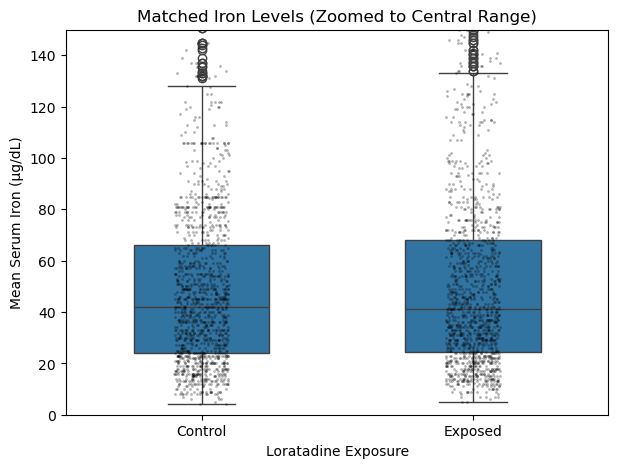

In [116]:
plt.figure(figsize=(7,5))
sns.boxplot(data=matched, x='loratadine_flag', y='iron_mean', width=0.5)
sns.stripplot(data=matched, x='loratadine_flag', y='iron_mean',
              color='black', size=2, alpha=0.3)

plt.ylim(0, 150)  # tighten to the clinically relevant range
plt.xticks([0,1], ['Control', 'Exposed'])
plt.ylabel("Mean Serum Iron (µg/dL)")
plt.xlabel("Loratadine Exposure")
plt.title("Matched Iron Levels (Zoomed to Central Range)")
plt.show()


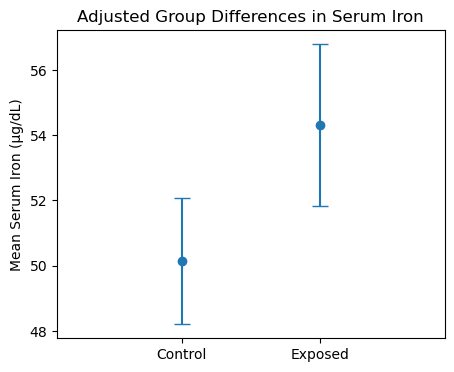

In [127]:
import numpy as np
from scipy import stats

def mean_ci(x):
    mean = np.mean(x)
    sem  = stats.sem(x)
    ci   = sem * 1.96
    return mean, ci

m_control, ci_control = mean_ci(matched[matched.loratadine_flag==0]['iron_mean'])
m_exposed, ci_exposed = mean_ci(matched[matched.loratadine_flag==1]['iron_mean'])

means = [m_control, m_exposed]
cis = [ci_control, ci_exposed]

plt.figure(figsize=(5,4))
plt.errorbar([0,1], means, yerr=cis, fmt='o', capsize=6)
plt.xticks([0,1], ['Control', 'Exposed'])
plt.ylabel("Mean Serum Iron (µg/dL)")
plt.title("Adjusted Group Differences in Serum Iron")

plt.xticks([0,1], ['Control', 'Exposed'])
plt.ylabel("Mean Serum Iron (µg/dL)")
plt.title("Adjusted Group Differences in Serum Iron")

plt.xlim(-0.9, 1.9)   # tighten spacing


plt.savefig('group_diff.svg', bbox_inches='tight')
plt.show()


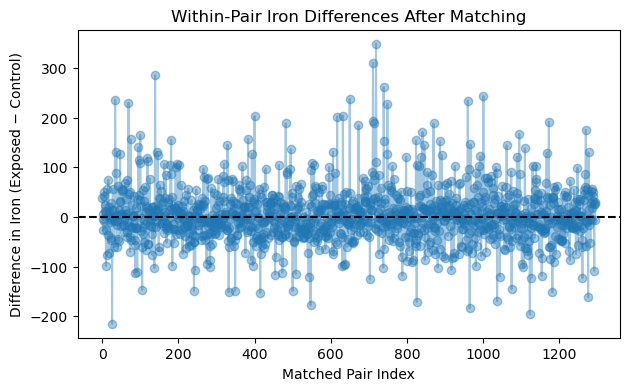

In [118]:
pairs = matched.sort_values('match_id')  # if you stored match IDs
control_vals = pairs[pairs.loratadine_flag==0]['iron_mean'].values
exposed_vals = pairs[pairs.loratadine_flag==1]['iron_mean'].values
diffs = exposed_vals - control_vals

plt.figure(figsize=(7,4))
plt.plot(diffs, marker='o', linestyle='-', alpha=0.4)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Difference in Iron (Exposed − Control)")
plt.xlabel("Matched Pair Index")
plt.title("Within-Pair Iron Differences After Matching")
plt.show()


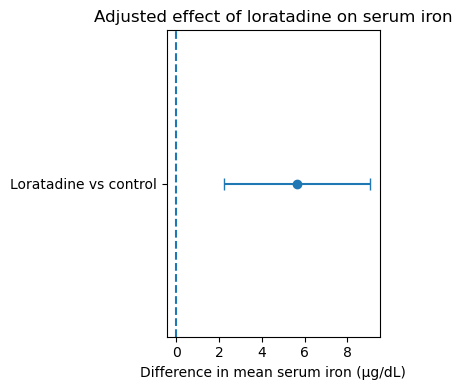

In [121]:
import numpy as np
import pandas as pd

def compute_smd(df, covariates, treat_col='loratadine_flag'):
    smd_list = []
    t = df[df[treat_col] == 1]
    c = df[df[treat_col] == 0]
    for col in covariates:
        m1 = t[col].mean()
        m0 = c[col].mean()
        v1 = t[col].var()
        v0 = c[col].var()
        sd_pooled = np.sqrt((v1 + v0) / 2.0)
        if sd_pooled == 0 or np.isnan(sd_pooled):
            smd = np.nan
        else:
            smd = (m1 - m0) / sd_pooled
        smd_list.append({'covariate': col, 'SMD': smd})
    return pd.DataFrame(smd_list)


import matplotlib.pyplot as plt

# Extract loratadine effect and CI from your fitted model
coef = model.params['loratadine_flag']
ci_low, ci_high = model.conf_int().loc['loratadine_flag']

fig, ax = plt.subplots(figsize=(4, 4))

# Single point with horizontal CI bar
ax.errorbar(
    x=coef,
    y=0,
    xerr=[[coef - ci_low], [ci_high - coef]],
    fmt='o',
    capsize=4
)

ax.axvline(0, linestyle='--')  # null line

ax.set_yticks([0])
ax.set_yticklabels(['Loratadine vs control'])

ax.set_xlabel('Difference in mean serum iron (µg/dL)')
ax.set_title('Adjusted effect of loratadine on serum iron')

plt.tight_layout()
plt.savefig('forest-line.svg', bbox_inches='tight')
plt.show()


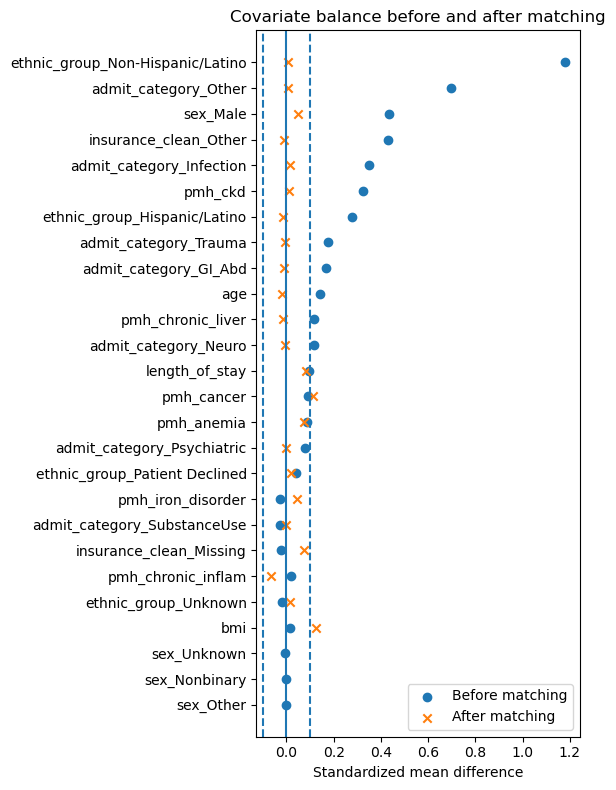

In [120]:
# Compute SMDs
smd_before = compute_smd(psm_data, covariate_cols)
smd_after  = compute_smd(matched,   covariate_cols)

# Merge for plotting
smd_plot = smd_before.merge(
    smd_after,
    on='covariate',
    suffixes=('_before', '_after')
)

# Sort by absolute SMD_before (largest to smallest)
smd_plot = smd_plot.reindex(
    smd_plot['SMD_before'].abs().sort_values(ascending=False).index
)

# Make Love plot
fig, ax = plt.subplots(figsize=(6, 8))

y_pos = np.arange(len(smd_plot))

ax.scatter(smd_plot['SMD_before'], y_pos, label='Before matching')
ax.scatter(smd_plot['SMD_after'],  y_pos, label='After matching', marker='x')

ax.axvline(0, linestyle='-')
ax.axvline(0.1, linestyle='--')
ax.axvline(-0.1, linestyle='--')

ax.set_yticks(y_pos)
ax.set_yticklabels(smd_plot['covariate'])
ax.invert_yaxis()  # top covariate at top

ax.set_xlabel('Standardized mean difference')
ax.set_title('Covariate balance before and after matching')
ax.legend()

plt.tight_layout()
plt.savefig('covariate balance.svg', bbox_inches='tight')
plt.show()
